In [ ]:
# Assuming this will be run on Google Colab with CPU
from google.colab import drive
drive.mount('/content/drive')

# Please set the path according to the local environment
!ls '/content/drive/MyDrive/pitch_type_pred/'
%cd "/content/drive/MyDrive/pitch_type_pred/"

Mounted at /content/drive
dataset  dataset2  program  results
/content/drive/MyDrive/pitch_type_pred


In [ ]:
import numpy as np
import os
import scipy.io
import glob
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load dataset from mat files
player_name="sub01" #sub01-08
temp_name="./dataset_va/"+player_name+"/*.mat"
mat_files = sorted(glob.glob(temp_name))

data_list = []
for f in mat_files:
    mat_data = scipy.io.loadmat(f)
    data_list.append(mat_data)

print(f"The total pitch number {len(data_list)}")

# "X_v" includes angle velocity information
# "X_va" includes angle velocity and accelaration information
T = data_list[0]["X_va"].shape[0]
D = data_list[0]["X_va"].shape[1]
print("Time length:", T, " Number of input features:", D)

The total pitch number 111
Time length: 101  Number of input features: 39


In [ ]:
# Full-joint condition
n_train_per_class = 25 # Number of pitches for per label in train data
n_test_per_class = 5 # Number of pitches for per label in test data
n_repeats = 100 # Number of tests on a specific dataset
np.random.seed(0)

acc_means, acc_stds = [], []
for t in range(T):
    print(t)

    X_t = np.array([d["X_va"][t, :] for d in data_list])
    y_t = np.array([int(np.squeeze(d["Ball_type_binary"])) for d in data_list])

    accs = []
    dists0 = []
    dists1 = []

    for rep in range(n_repeats):
        idx_0 = np.where(y_t == 0)[0]
        idx_1 = np.where(y_t == 1)[0]

        train_idx_0 = np.random.choice(idx_0, size=n_train_per_class, replace=False)
        train_idx_1 = np.random.choice(idx_1, size=n_train_per_class, replace=False)

        remain_0 = np.setdiff1d(idx_0, train_idx_0)
        remain_1 = np.setdiff1d(idx_1, train_idx_1)
        test_idx_0 = np.random.choice(remain_0, size=n_test_per_class, replace=False)
        test_idx_1 = np.random.choice(remain_1, size=n_test_per_class, replace=False)

        train_idx = np.concatenate([train_idx_0, train_idx_1])
        test_idx  = np.concatenate([test_idx_0, test_idx_1])

        X_train, y_train = X_t[train_idx], y_t[train_idx]
        X_test,  y_test  = X_t[test_idx],  y_t[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test) # For avoiding the information leak

        #Fit the LR model
        clf = LogisticRegression(max_iter=1000, solver='lbfgs', penalty='l2')
        clf.fit(X_train, y_train)

        accs.append(clf.score(X_test, y_test))

    acc_means.append(np.mean(accs))
    acc_stds.append(np.std(accs))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


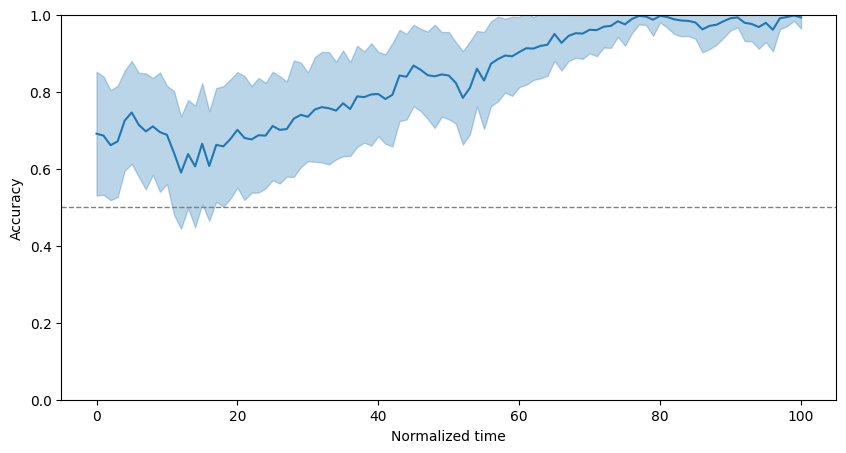

Saved: ./results/csv/acc_timecourse_logist_va_sub08.csv


In [ ]:
# Visualize the results
t_range = np.arange(T)

plt.figure(figsize=(10,5))
plt.plot(t_range, acc_means, color='C0', label="Accuracy (mean)")
plt.fill_between(t_range,
                 np.array(acc_means) - np.array(acc_stds),
                 np.array(acc_means) + np.array(acc_stds),
                 color='C0', alpha=0.3)
plt.ylim(0.0, 1.0)
n0, n1 = len(idx_0), len(idx_1)
chance_acc = max(n0, n1) / (n0 + n1)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Normalized time")
plt.ylabel("Accuracy")
temp_name="./results/images/accuracy_plot_logist_va_"+player_name+".pdf"
plt.savefig(temp_name, dpi=300, bbox_inches="tight")
plt.show()

# save the prediction results
df = pd.DataFrame({
    "t": np.arange(len(acc_means)),
    "acc_mean": acc_means,
    "acc_std": acc_stds,
})

csv_path = os.path.join("./results/csv", f"acc_timecourse_logist_va_{player_name}.csv")
df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("Saved:", csv_path)

In [ ]:
from google.colab import runtime
runtime.unassign()